In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=sns.load_dataset("tips")#loading library from seaborn
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<function matplotlib.pyplot.show(close=None, block=None)>

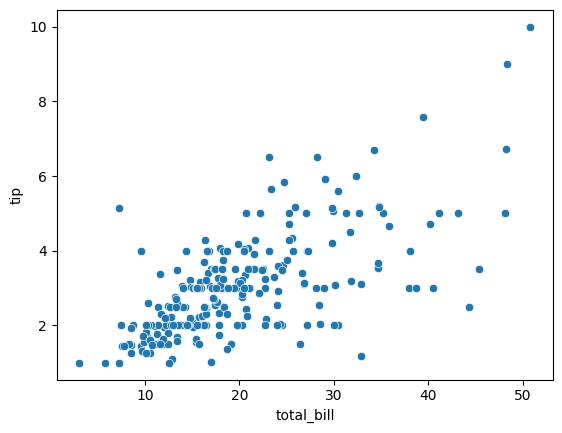

In [4]:
sns.scatterplot(x='total_bill',y='tip',data=df) 
plt.show

In [5]:
df=pd.get_dummies(df,drop_first=True)
X=df.drop("tip",axis=1) # sklearn expect 2 D array 
y=df['tip']

In [6]:
from sklearn.model_selection import train_test_split
x_test,x_train,y_test,y_train=train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [8]:
y_pred=model.predict(x_test)
from sklearn.metrics import mean_squared_error,r2_score

In [9]:
print("MSE : ",mean_squared_error(y_test,y_pred))
print("r2 score : ",r2_score(y_test,y_pred)) 

MSE :  1.433617678153846
r2 score :  0.29437789795472336


In [10]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("CV R² scores:", scores)
print("Mean R²:", scores.mean())

CV R² scores: [0.37721486 0.52623646 0.50857308 0.212601   0.36055579]
Mean R²: 0.3970362356469822


In [12]:
from sklearn.model_selection import GridSearchCV

param_gram={'n_estimators':[50,100,200], 'max_depth':[None,10,20],'min_samples_split':[2,5,10]} 
# n estimators is no of trees in the forest,max depth of tree,minimum sample to split a node 
rf_base=RandomForestRegressor(random_state=42)

grid_search=GridSearchCV(estimator=rf_base, param_grid=param_gram, cv=3, scoring='accuracy',n_jobs=-1)

In [16]:
print("Searching for the best parameters ,this might take some time......")
grid_search.fit(x_train,y_train)


Searching for the best parameters ,this might take some time......


c:\Users\nidhi\Documents\programming\python_programming\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, defau

In [17]:
print("best parameters :",grid_search.best_params_)
pd.DataFrame(grid_search.cv_results_)

best parameters : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.649202,0.058228,0.072365,0.007804,None,2,50,"{'max_depth': None, 'min_samples_split': 2, 'n...",NaN,NaN,NaN,NaN,NaN,1
1,0.805648,0.071130,0.250488,0.259736,None,2,100,"{'max_depth': None, 'min_samples_split': 2, 'n...",NaN,NaN,NaN,NaN,NaN,1
2,1.332208,0.047603,0.123077,0.014036,None,2,200,"{'max_depth': None, 'min_samples_split': 2, 'n...",NaN,NaN,NaN,NaN,NaN,1
3,0.326792,0.021767,0.042942,0.002828,None,5,50,"{'max_depth': None, 'min_samples_split': 5, 'n...",NaN,NaN,NaN,NaN,NaN,1
4,0.662855,0.026483,0.066402,0.006568,None,5,100,"{'max_depth': None, 'min_samples_split': 5, 'n...",NaN,NaN,NaN,NaN,NaN,1
5,1.262237,0.055323,0.113830,0.006125,None,5,200,"{'max_depth': None, 'min_samples_split': 5, 'n...",NaN,NaN,NaN,NaN,NaN,1
6,0.315046,0.013451,0.042298,0.005384,None,10,50,"{'max_depth': None, 'min_samples_split': 10, '...",NaN,NaN,NaN,NaN,NaN,1
7,0.625699,0.010939,0.071754,0.012481,None,10,100,"{'max_depth': None, 'min_samples_split': 10, '...",NaN,NaN,NaN,NaN,NaN,1
8,1.232130,0.026534,0.112251,0.014543,None,10,200,"{'max_depth': None, 'min_samples_split': 10, '...",NaN,NaN,NaN,NaN,NaN,1
9,0.317998,0.024969,0.047540,0.000771,10,2,50,"{'max_depth': 10, 'min_samples_split': 2, 'n_e...",NaN,NaN,NaN,NaN,NaN,1
